# Proje amacı

Bu projenin amacı, bir kişinin temel biyometrik ölçümlerini ve kan tahlili sonuçlarını (hemoglobin, kolesterol, karaciğer enzimleri vb.) analiz ederek, o kişinin sigara içip içmediğini tahmin eden yüksek doğruluklu bir makine öğrenmesi modeli geliştirmektir.

Kısaca Proje Özeti:

Problem Tipi: İkili Sınıflandırma (Binary Classification).

Veri Odak Noktası: Vücut kimyasındaki değişimlerin (özellikle karaciğer enzimleri ve kan değerleri) sigara kullanımıyla olan güçlü korelasyonunu yakalamak.

Teknik Hedef: Karmaşık tıbbi veriler arasındaki doğrusal olmayan ilişkileri LightGBM gibi gelişmiş algoritmalarla modelleyerek, gerçek hayat verilerinde en yüksek ROC-AUC skoruna ulaşmak.

Kullanım Alanı: Sağlık taramalarında eksik beyanların tespiti veya risk analizleri için yardımcı bir dijital araç oluşturmak.

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score

In [3]:
# Veriyi yükle
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# EDA

In [5]:
#ilk 5 satırı göster
train.head()

,id,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
0,0,55,165,60,81.0,0.5,0.6,1,1,135,...,40,75,16.5,1,1.0,22,25,27,0,1
1,1,70,165,65,89.0,0.6,0.7,2,2,146,...,57,126,16.2,1,1.1,27,23,37,1,0
2,2,20,170,75,81.0,0.4,0.5,1,1,118,...,45,93,17.4,1,0.8,27,31,53,0,1
3,3,35,180,95,105.0,1.5,1.2,1,1,131,...,38,102,15.9,1,1.0,20,27,30,1,0
4,4,30,165,60,80.5,1.5,1.0,1,1,121,...,44,93,15.4,1,0.8,19,13,17,0,1


In [6]:
#son 5 satırı göster
train.tail()

,id,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
159251,159251,40,155,45,69.0,1.5,2.0,1,1,127,...,72,159,14.5,1,0.8,25,26,13,0,0
159252,159252,50,155,75,82.0,1.0,1.0,1,1,120,...,64,108,14.5,1,0.6,21,20,18,0,0
159253,159253,40,160,50,66.0,1.5,1.0,1,1,114,...,87,93,10.9,1,0.6,15,9,12,0,0
159254,159254,50,165,75,92.0,1.2,1.0,1,1,121,...,55,80,14.4,1,1.1,22,17,37,0,1
159255,159255,40,145,45,76.4,1.0,1.2,1,1,125,...,87,81,14.0,1,0.8,21,16,17,0,0


In [7]:
#veriler hk bilgi
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159256 entries, 0 to 159255
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id                   159256 non-null  int64  
 1   age                  159256 non-null  int64  
 2   height(cm)           159256 non-null  int64  
 3   weight(kg)           159256 non-null  int64  
 4   waist(cm)            159256 non-null  float64
 5   eyesight(left)       159256 non-null  float64
 6   eyesight(right)      159256 non-null  float64
 7   hearing(left)        159256 non-null  int64  
 8   hearing(right)       159256 non-null  int64  
 9   systolic             159256 non-null  int64  
 10  relaxation           159256 non-null  int64  
 11  fasting blood sugar  159256 non-null  int64  
 12  Cholesterol          159256 non-null  int64  
 13  triglyceride         159256 non-null  int64  
 14  HDL                  159256 non-null  int64  
 15  LDL              

In [8]:
#kaç satır kaç sütun
train.shape

(159256, 24)

In [15]:
#verilerin istatiksel bilgiler
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,159256.0,79627.500000,45973.391572,0.0,39813.75,79627.5,119441.25,159255.0
age,159256.0,44.306626,11.842286,20.0,40.00,40.0,55.00,85.0
height(cm),159256.0,165.266929,8.818970,135.0,160.00,165.0,170.00,190.0
weight(kg),159256.0,67.143662,12.586198,30.0,60.00,65.0,75.00,130.0
waist(cm),159256.0,83.001990,8.957937,51.0,77.00,83.0,89.00,127.0
eyesight(left),159256.0,1.005798,0.402113,0.1,0.80,1.0,1.20,9.9
eyesight(right),159256.0,1.000989,0.392299,0.1,0.80,1.0,1.20,9.9
hearing(left),159256.0,1.023974,0.152969,1.0,1.00,1.0,1.00,2.0
hearing(right),159256.0,1.023421,0.151238,1.0,1.00,1.0,1.00,2.0
systolic,159256.0,122.503648,12.729315,77.0,114.00,121.0,130.00,213.0


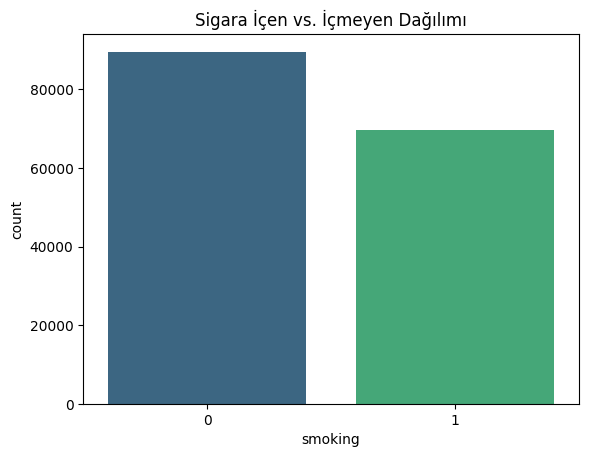

In [11]:
sns.countplot(x='smoking', data=train, hue='smoking', palette='viridis', legend=False)
plt.title('Sigara İçen vs. İçmeyen Dağılımı')
plt.show()

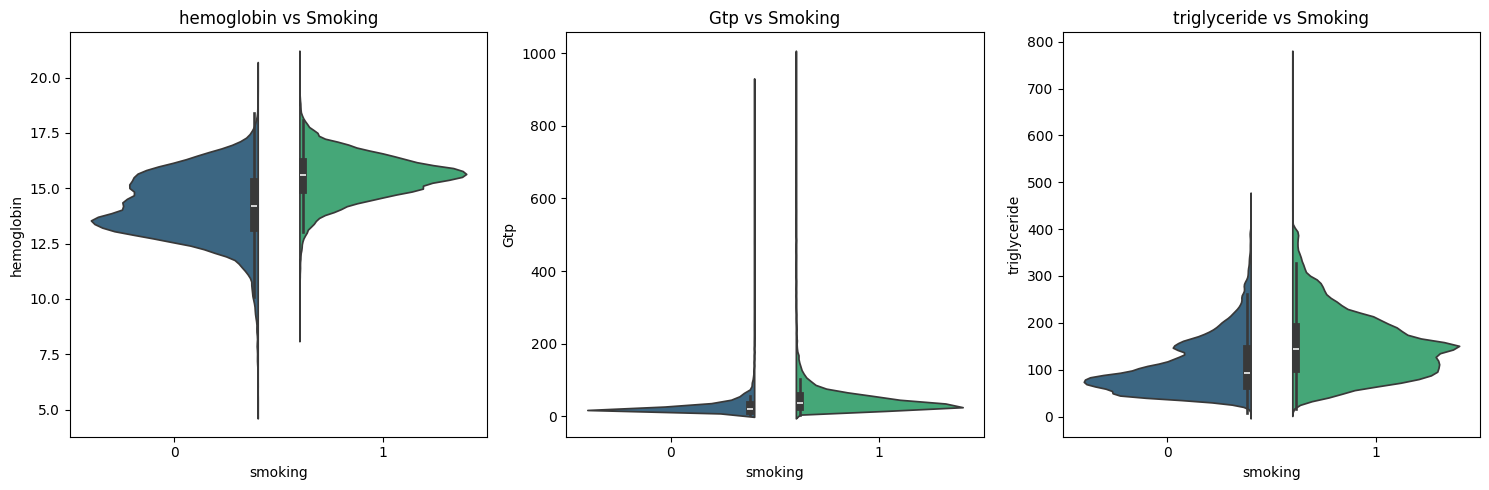

In [13]:
features_to_plot = ['hemoglobin', 'Gtp', 'triglyceride']

plt.figure(figsize=(15, 5))
for i, col in enumerate(features_to_plot):
    plt.subplot(1, 3, i+1)
    sns.violinplot(x='smoking', y=col, hue='smoking', data=train, split=True, palette='viridis', legend=False)
    plt.title(f'{col} vs Smoking')

plt.tight_layout()
plt.show()

Sigara ile en çok ilişkili özellikler:
 smoking             1.000000
hemoglobin          0.450679
height(cm)          0.447111
weight(kg)          0.351748
triglyceride        0.331975
Gtp                 0.305561
serum creatinine    0.272979
waist(cm)           0.262715
ALT                 0.163016
eyesight(right)     0.109781
Name: smoking, dtype: float64


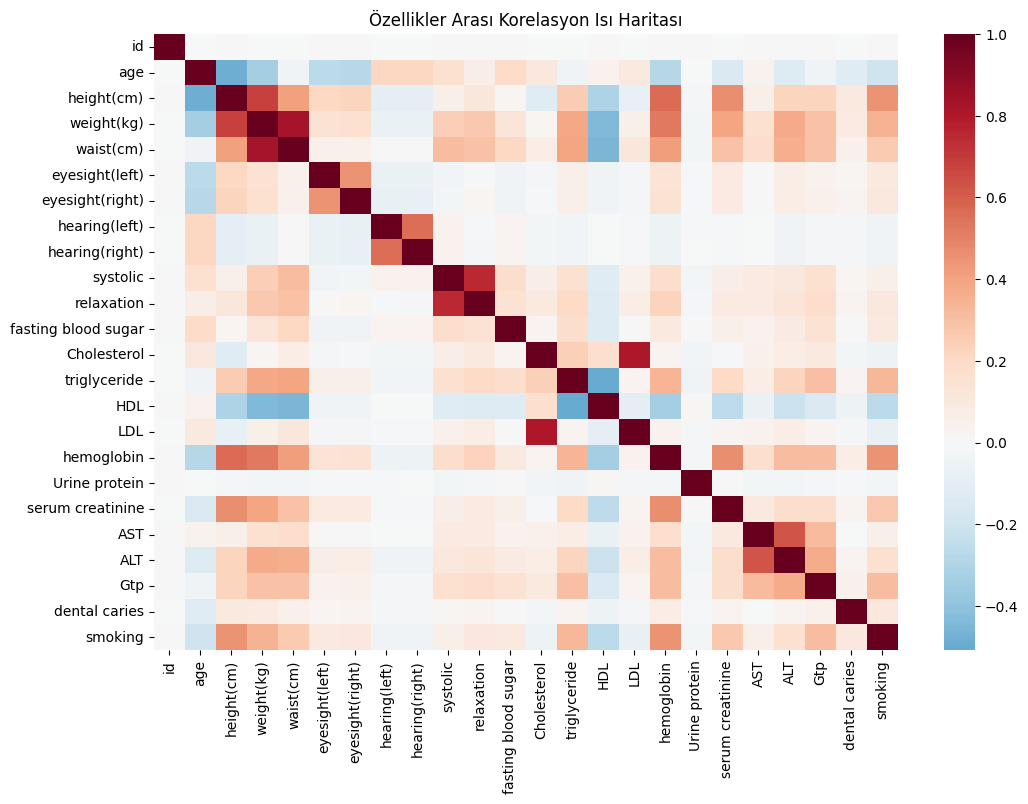

In [14]:
plt.figure(figsize=(12, 8))
# Sadece sayısal sütunları alalım
numeric_train = train.select_dtypes(include=['float64', 'int64'])
corr = numeric_train.corr()

# smoking ile en çok korele olan ilk 10 özelliği görelim
top_corr = corr['smoking'].sort_values(ascending=False).head(10)
print("Sigara ile en çok ilişkili özellikler:\n", top_corr)

# Isı haritası
sns.heatmap(corr, annot=False, cmap='RdBu_r', center=0)
plt.title('Özellikler Arası Korelasyon Isı Haritası')
plt.show()

# Feature Engineering

In [20]:
def apply_feature_engineering(df):
    
    # 1. Log Dönüşümleri (Uç değerleri sıkıştırmak için)
    # np.log1p kullanıyoruz çünkü 0 olan değerlerde hata almamızı engeller (log(1+x))
    df['log_Gtp'] = np.log1p(df['Gtp'])
    df['log_triglyceride'] = np.log1p(df['triglyceride'])
    df['log_ALT'] = np.log1p(df['ALT'])
    df['log_LDL'] = np.log1p(df['LDL'])

    # 2. Sağlık İndeksleri ve Oranlar
    # Vücut Kitle Endeksi (BMI)
    df['bmi'] = df['weight(kg)'] / ((df['height(cm)'] / 100) ** 2)
    
    # Karaciğer Fonksiyon Oranı (De Ritis Oranı)
    df['ast_alt_ratio'] = df['AST'] / df['ALT']
    
    # Kolesterol Dengesi
    df['chol_hdl_ratio'] = df['Cholesterol'] / df['HDL']
    
    # 3. Kritik Eşikler (Binary Flags)
    # Sigara ile yüksek korelasyonlu olan hemo ve Gtp için "yüksek" bayrakları
    df['is_high_hemo'] = (df['hemoglobin'] > 16).astype(int)
    df['is_high_gtp'] = (df['Gtp'] > 60).astype(int)
    
    # 4. Gereksiz Sütunları Eleme
    # 'id' tahminde kullanılmaz, gürültü yaratmasın
    if 'id' in df.columns:
        df = df.drop('id', axis=1)
        
    return df

# Uygulayalım
train_df = apply_feature_engineering(train)
test_df = apply_feature_engineering(test)

# model eğitimi

In [21]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# X ve y hazırlığı
X = train_df.drop('smoking', axis=1)
y = train_df['smoking']

# 5-Katlı Çapraz Doğrulama (Cross-Validation)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = []
test_preds = []

for i, (train_index, val_index) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    
    model = LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=9,
        num_leaves=31,
        random_state=42,
        verbosity=-1
    )
    
    # eval_set kullanarak modelin her adımda gelişimini izleyelim
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='auc')

    # Tahmin ve Skor
    val_preds = model.predict_proba(X_val)[:, 1]
    scores.append(roc_auc_score(y_val, val_preds))
    
    # Yarışma için test tahminlerini topluyoruz (Ağırlıklı ortalama için)
    test_preds.append(model.predict_proba(test_df)[:, 1])

print(f"Ortalama Skor: {np.mean(scores):.5f}")

Ortalama Skor: 0.86732


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.84      0.76      0.80     17921
           1       0.73      0.81      0.77     13930

    accuracy                           0.78     31851
   macro avg       0.78      0.79      0.78     31851
weighted avg       0.79      0.78      0.78     31851



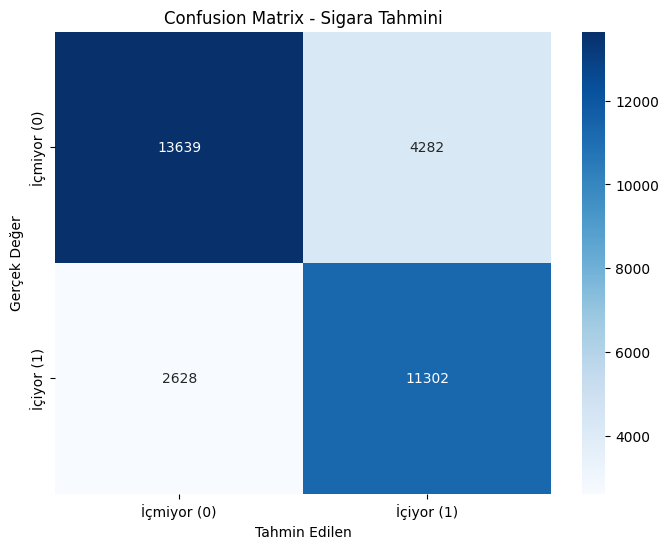

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Validation seti üzerinden tahminleri al (0 veya 1 olarak)

y_pred = model.predict(X_val)

# 2. Classification Report (Metrik Tablosu)
print("--- Classification Report ---")
print(classification_report(y_val, y_pred))

# 3. Confusion Matrix Görselleştirme
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['İçmiyor (0)', 'İçiyor (1)'], 
            yticklabels=['İçmiyor (0)', 'İçiyor (1)'])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Confusion Matrix - Sigara Tahmini')
plt.show()

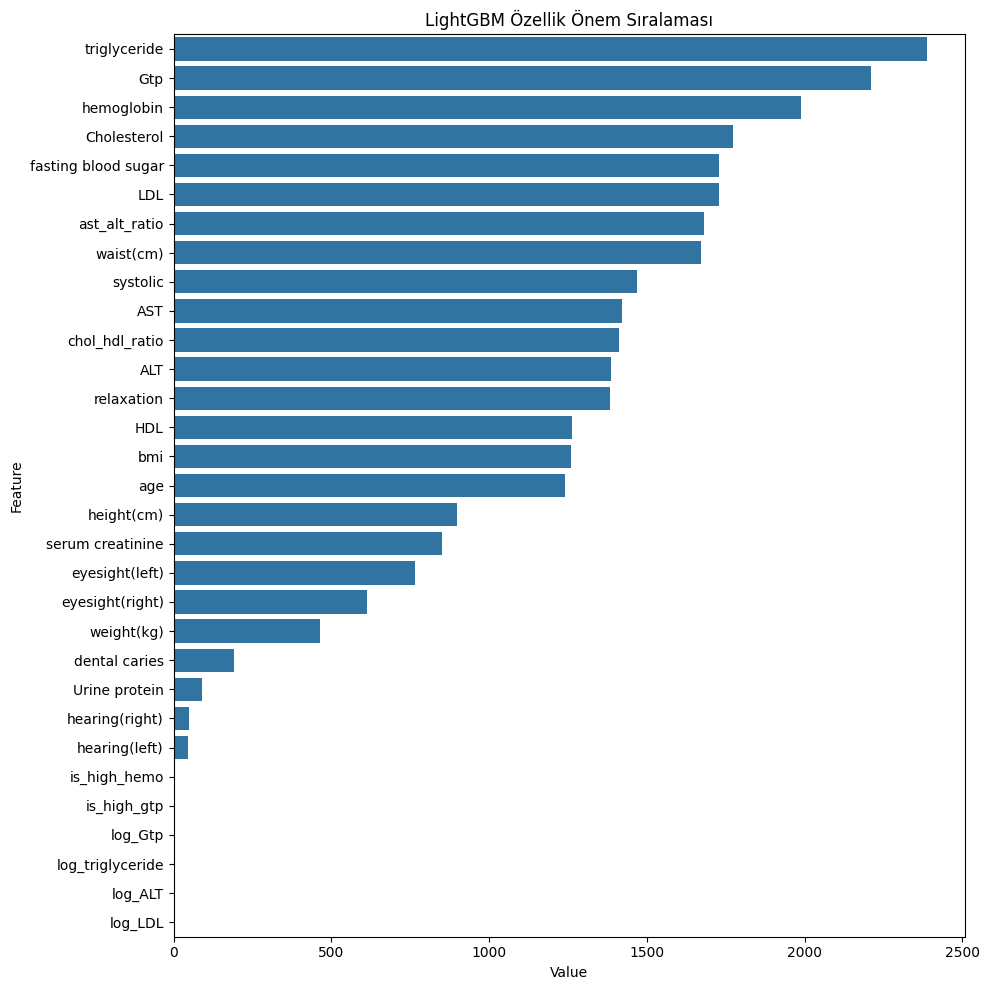

In [29]:
# Özellik önem düzeylerini görselleştirme
feature_imp = pd.DataFrame({'Value': model.feature_importances_, 'Feature': X.columns})
plt.figure(figsize=(10, 10))
sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False))
plt.title('LightGBM Özellik Önem Sıralaması')
plt.tight_layout()
plt.show()

In [22]:
# Tüm katmanların tahminlerini ortala
final_predictions = np.mean(test_preds, axis=0)

# Submission dosyasını oku ve doldur
submission = pd.read_csv('sample_submission.csv')
submission['smoking'] = final_predictions
submission.to_csv('submission_lgbm_v1.csv', index=False)

In [24]:
# Modeli kaydet
import joblib

# Modeli bir 'pickle' dosyası olarak kaydet
joblib.dump(model, 'lgbm_smoking_model.pkl')

print("Model 'lgbm_smoking_model.pkl' olarak kaydedildi.")

# Geri yüklemek için:
# loaded_model = joblib.load('lgbm_smoking_model.pkl')

Model 'lgbm_smoking_model.pkl' olarak kaydedildi.


# Sonuç

Model: 5-Fold Stratified LightGBM kullandık.

Strateji: Verideki uç değerleri (Gtp, ALT, Triglyceride) Log Dönüşümü ile törpüledik ve BMI gibi tıbbi oranlar ekleyerek modelin işini kolaylaştırdık.

CV Skoru (0.8673): Modelinin kendi içindeki tutarlılığını kanıtladı.

Public Skor (0.8669): Gerçek veri üzerindeki başarını tescilledi. İki skor arasındaki farkın çok az olması, modelinin çok güvenilir (robust) olduğunu gösteriyor.